## Seaborn pour des représentations plus élaborées
### Utilisation de Seaborn

Seaborn est un autre package intéressant pour la création de graphiques. Il est
basé sur Matplotlib et en utilise les principes. Son principal intérêt réside dans la création de graphiques plus spécifiques en quelques lignes de code.

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

### Le box-plot ou la boîte à moustaches

Un box plot (appelé aussi une boîte à moustache) est un graphique utilisé fréquemment pour l’exploration des données. Il permet de visualiser pour une variable ou pour un groupe d’individus le comportement global des individus.

Nous utiliserons ici des données de la région Île-de-France sur les communes de
la (données open data Île-de-France). 

In [7]:
# on récupère les données
data_idf=pd.read_csv("data/base-comparateur-de-territoires.csv",sep=";")

data_idf

,CODGEO,LIBGEO,REG,DEP,P14_POP,P09_POP,SUPERF,NAIS0914,DECE0914,P14_MEN,...,ETAZ15,ETBE15,ETFZ15,ETGU15,ETGZ15,ETOQ15,ETTEF115,ETTEFP1015,Geo Shape,geo_point_2d
0,95555,Saint-Gratien,11,95,20996.0,20258.0,2.42,1564.0,749.0,8909.817815,...,3.0,38.0,142.0,1078.0,225.0,214.0,335.0,67.0,"{""type"": ""Polygon"", ""coordinates"": [[[2.274621...","48.9695044801, 2.28470111182"
1,95488,Pierrelaye,11,95,8155.0,7920.0,9.21,639.0,243.0,2891.000000,...,8.0,47.0,135.0,623.0,241.0,65.0,228.0,72.0,"{""type"": ""Polygon"", ""coordinates"": [[[2.193617...","49.0190794714, 2.1606870483"
2,95543,Saint-Cyr-en-Arthies,11,95,242.0,229.0,3.89,9.0,4.0,93.154812,...,2.0,0.0,2.0,5.0,2.0,4.0,4.0,0.0,"{""type"": ""Polygon"", ""coordinates"": [[[1.732068...","49.058878265, 1.74176317637"
3,95523,La Roche-Guyon,11,95,446.0,447.0,4.61,18.0,21.0,186.507593,...,0.0,6.0,6.0,48.0,17.0,14.0,13.0,4.0,"{""type"": ""Polygon"", ""coordinates"": [[[1.623323...","49.0883415268, 1.63442788467"
4,95678,Villiers-Adam,11,95,838.0,828.0,9.82,45.0,29.0,340.831981,...,6.0,3.0,8.0,53.0,12.0,5.0,14.0,2.0,"{""type"": ""Polygon"", ""coordinates"": [[[2.236020...","49.0697597649, 2.23847351378"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,95582,Sannois,11,95,26826.0,25856.0,4.78,2111.0,753.0,10363.061937,...,3.0,60.0,273.0,1365.0,297.0,247.0,419.0,86.0,"{""type"": ""Polygon"", ""coordinates"": [[[2.274621...","48.971575438, 2.25336384763"
1296,95563,Saint-Leu-la-Forêt,11,95,15072.0,14783.0,5.24,910.0,551.0,6033.502470,...,3.0,71.0,199.0,876.0,177.0,247.0,301.0,45.0,"{""type"": ""Polygon"", ""coordinates"": [[[2.253146...","49.0187947257, 2.24666220276"
1297,95682,Villiers-le-Sec,11,95,177.0,176.0,3.26,14.0,3.0,70.000000,...,5.0,3.0,6.0,9.0,3.0,2.0,9.0,0.0,"{""type"": ""Polygon"", ""coordinates"": [[[2.370400...","49.0745767074, 2.38634517834"
1298,95610,Théméricourt,11,95,278.0,259.0,7.58,17.0,5.0,109.978022,...,5.0,1.0,1.0,31.0,10.0,3.0,10.0,2.0,"{""type"": ""Polygon"", ""coordinates"": [[[1.904456...","49.0908194723, 1.90500672567"


On représente le box-plot du nombre de naissances par commune en fonction du département d’Île-de-France :

Text(0.5, 1.0, 'Box plot du nombre de naissances par habitant par département')

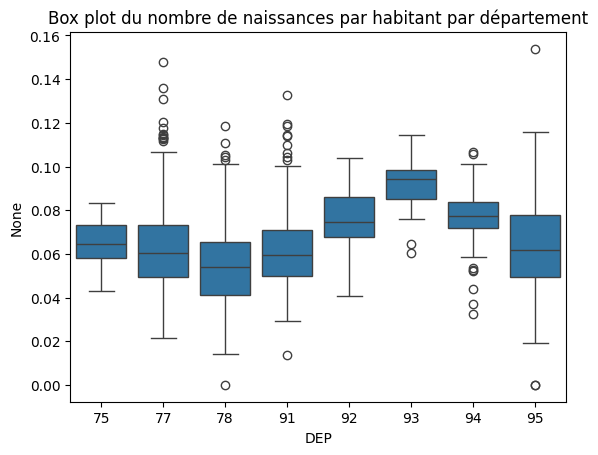

In [8]:
sns.boxplot(x=data_idf["DEP"], y=data_idf["NAIS0914"]/ data_idf["P09_POP"])
plt.title("Box plot du nombre de naissances par habitant par département")

Les box plots de Seaborn offrent d’autres possibilités, notamment d’utiliser le paramètre *data =* qui va simplifier notre code :

Text(0.5, 1.0, 'Box-plot entaillé par département')

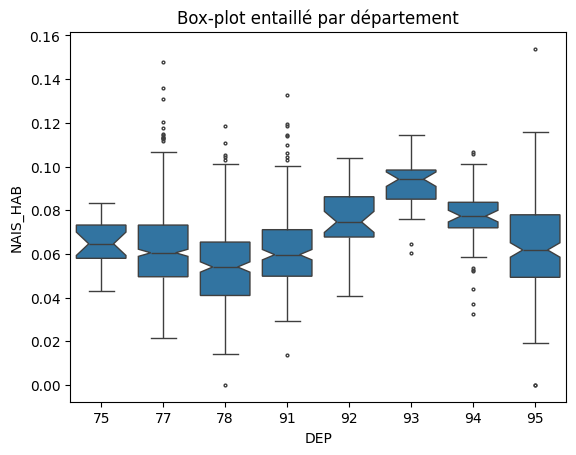

In [9]:
# on crée une nouvelle colonne
data_idf["NAIS_HAB"]= data_idf["NAIS0914"]/data_idf["P09_POP"]
# on crée le box plot
sns.boxplot(x="DEP",y="NAIS_HAB", data=data_idf, linewidth=1, 
            notch=True, fliersize=2)
plt.title("Box-plot entaillé par département")

### Les distplot() de Seaborn

Les distplot de Seaborn sont des visualisations des distributions de probabilité des variables quantitatives. 

Ce graphique se rapproche beaucoup des histogrammes mais il ajoute la représentation de la distribution empirique des données.

<Axes: ylabel='Count'>

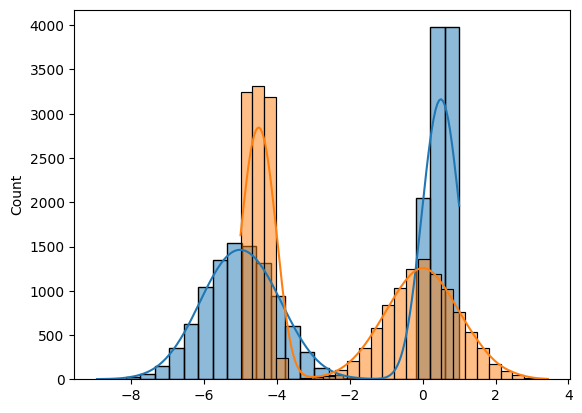

In [15]:
# on génère des données
var=np.concatenate([np.random.randn(10000)-5, 
                    np.random.beta(1,1, size=10000)],
                   axis=0)
var2=np.concatenate([np.random.randn(10000), 
                     np.random.beta(1,1,size=10000)-5],
                    axis=0)
# on affiche les distributions
sns.histplot(var,kde=True)
sns.histplot(var2,kde=True)

### Les pairplot() de Seaborn ou la matrice de graphiques

Le pairplot de Seaborn est un outil très efficace pour représenter les variables
quantitatives d’un DataFrame (à condition de ne pas trop en avoir).

Un pairplot va construire une figure avec à l’intérieur une matrice de graphiques.

Les éléments sur la diagonale sont des distplot et les éléments hors de la diagonale sont des nuages de points qui croisent les variables deux à deux.

Si nous essayons de représenter ce graphique par département sur les données
de la région Ile-de-France :

In [16]:
data_idf['DEP'] = data_idf['DEP'].astype('category')

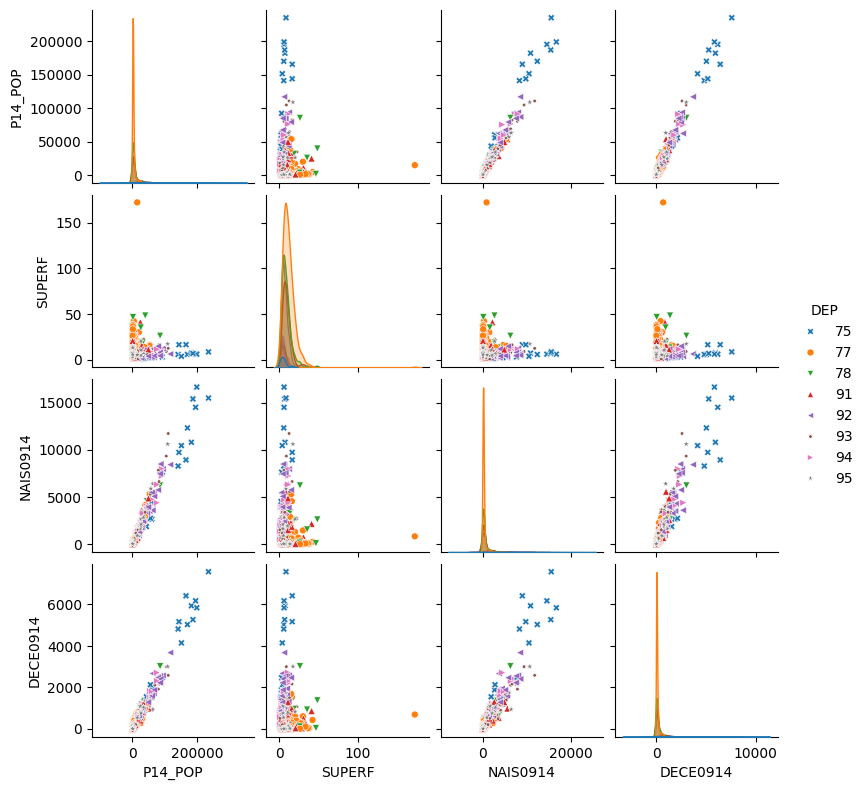

In [17]:
sns.pairplot(data=data_idf, hue='DEP',
vars=['P14_POP', 'SUPERF','NAIS0914', 'DECE0914'],
height=2, plot_kws={"s": 25},
markers=['X','o','v','^','<','.','>',"*"])


L’argument *plot_kws* est un argument qui permet de définir des propriétés plus spécifiques du graphique.

Il attend un dictionnaire de propriétés-valeurs. Ici on définit la taille des points dans les nuages de points.

### Les jointplot()

Le jointplot est un graphique qui permet de représenter le croisement entre deux
variables quantitatives. Il affiche simultanément un nuage de points et des histogrammes pour chaque variable.

Si nous travaillons sur le nombre de décès et de naissances en fonction de la population des communes d’Ile-de-France, nous aurons :

In [18]:
# construction de nouvelles variables
data_idf['DECE_HAB']=data_idf['DECE0914']/data_idf["P14_POP"]
data_idf['NAISS_HAB']=data_idf['NAIS0914']/data_idf["P14_POP"]

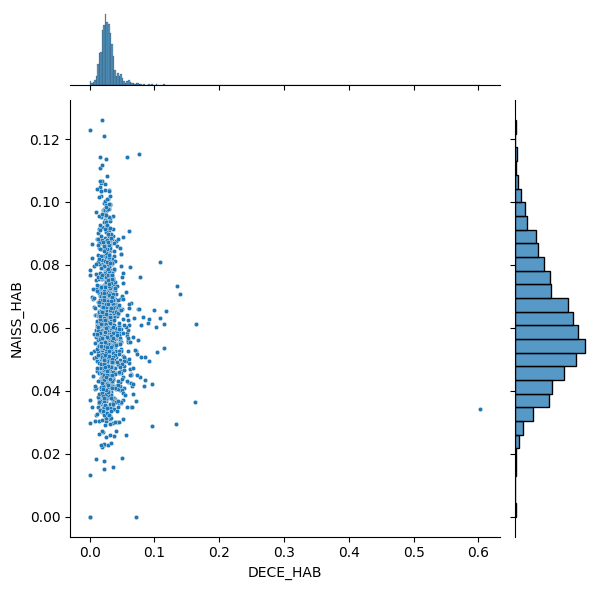

In [19]:
# représentation du jointplot
ax = sns.jointplot(x='DECE_HAB', 
                   y='NAISS_HAB', 
                   data=data_idf, 
                   joint_kws={"s": 10})

Il existe bien d'autres fonctionnalités de Matplotlib et Seaborn, n'hésitez pas à consulter la documentation des ces packages :
- https://matplotlib.org/ 
- https://seaborn.pydata.org/
- https://www.machinelearningplus.com/plots/top-50-matplotlib-visualizations-the-master-plots-python/#6.-Marginal-Histogram